In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, auc, accuracy_score,  classification_report, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import metrics
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [ ]:
# df_sissi = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
# df_sissiz_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx"))
# df_sissiz_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx"))
# df_multiperm_mono = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx"))
# df_multiperm_di = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx"))
# df_aln_shuffle = pd.DataFrame(pd.read_excel("C:/bla/Waste/MA/Data/SISSIz_Data_di_Excel/alifoldz.xlsx"))

In [ ]:
# df_sissi = pd.DataFrame(pd.read_excel("D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissi.xlsx"))
# df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'))
# df_sissiz_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx'))
# df_sissiz_mono = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx'))
# df_multiperm_di = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx'))
# df_aln_shuffle = pd.DataFrame(pd.read_excel('D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'))

In [15]:
# Datei-Pfade
file_names = {
    # 'sissi': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissi.xlsx',
    'sissi_oversampling': 'D:/Masterarbeit_programmieren/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx',
    'sissiz_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx',
    'sissiz_di': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_di.xlsx',
    'multiperm_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_mono.xlsx',
    'multiperm_di': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/multiperm_di.xlsx',
    'aln-shuffle': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/alifoldz.xlsx'
}

In [16]:
# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")

print(df)

       sissi_oversampling  sissiz_mono  sissiz_di  multiperm_mono  \
0                  -17.54         0.65       0.12           -5.48   
1                  -33.39         1.23       1.30           -7.34   
2                  -28.15         0.00       0.23           -5.99   
3                  -21.36         0.03       1.60           -9.41   
4                  -21.70         1.69       0.85           -7.75   
...                   ...          ...        ...             ...   
99995              -27.31         0.93       1.14           -8.72   
99996              -18.53        -0.82       0.92           -6.44   
99997              -22.00         0.01      -0.84           -4.33   
99998              -23.58         1.43       1.82           -4.54   
99999              -17.86        -0.45       0.43           -6.69   

       multiperm_di  aln-shuffle  
0             -3.87       -15.64  
1             -7.06       -11.03  
2             -5.05        -9.90  
3             -4.71       -11.2

In [26]:
sissi_oversampling = df["sissi_oversampling"].astype(float).describe().to_frame()
sissiz_mono = df["sissiz_mono"].astype(float).describe().to_frame()
sissiz_di = df["sissiz_di"].astype(float).describe().to_frame()
multiperm_mono = df["multiperm_mono"].astype(float).describe().to_frame()
multiperm_di = df["multiperm_di"].astype(float).describe().to_frame()
aln_shuffle = df["aln-shuffle"].astype(float).describe().to_frame()

summary = pd.concat([sissi_oversampling, sissiz_mono, multiperm_mono, multiperm_di, aln_shuffle], axis=1)
summary.columns = ["sissi_oversampling", "sissiz_mono", "multiperm_mono", "multiperm_di", "aln_shuffle"]

print(summary)

       sissi_oversampling    sissiz_mono  multiperm_mono   multiperm_di  \
count       100000.000000  100000.000000   100000.000000  100000.000000   
mean           -23.610500       0.719268       -5.303137      -5.153545   
std              4.450964       0.759088        1.802749       1.781275   
min            -35.900000      -3.890000      -16.640000     -14.560000   
25%            -26.117500       0.260000       -6.440000      -6.280000   
50%            -23.315000       0.830000       -5.170000      -5.030000   
75%            -20.842500       1.280000       -4.030000      -3.890000   
max            -13.940000       2.860000        0.520000       0.200000   

         aln_shuffle  
count  100000.000000  
mean      -12.387286  
std         3.457317  
min       -36.990000  
25%       -14.550000  
50%       -12.140000  
75%        -9.940000  
max        -2.070000  


In [27]:
def plot_roc_curve(fper, tper, y):
    plt.plot(fper, tper, color='red', label='ROC')
    plt.plot([0, 1], [0, 1], color='green', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(y)
    plt.legend()

In [28]:
def plot_confusion_matrix(x, z):
    group_names = ['True Neg','False Pos','False Neg','True Pos']

    group_counts = ["{0:0.0f}".format(value) for value in
                x.flatten()]

    group_percentages = ["{0:.2%}".format(value) for value in
                     x.flatten()/np.sum(x)]

    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in
          zip(group_names,group_counts,group_percentages)]

    labels = np.asarray(labels).reshape(2,2)

    ax = sns.heatmap(x, annot=labels, fmt='', cmap='Blues')

    ax.set_title(z)
    ax.set_xlabel('\nPredicted Values')
    ax.set_ylabel('Actual Values ')

    ## Ticket labels - List must be in alphabetical order
    ax.xaxis.set_ticklabels(['False','True'])
    ax.yaxis.set_ticklabels(['False','True'])

In [ ]:
df["multiperm_mono_binary"] = (df["multiperm_mono"] > -4).astype(int)

X_train, X_test, y_train, y_test = train_test_split(df[["sissi_oversampling"]], df["multiperm_mono_binary"], test_size=0.3, random_state=42)
print("X_train: " + str(X_train.shape))
print("y_train: " + str(y_train.shape))
print("X_test: " + str(X_test.shape))
print("y_test: " + str(y_test.shape))

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Logistische Regression durchführen
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen
y_pred = model.predict(X_test)

X_train: (70000, 1)
y_train: (70000,)
X_test: (30000, 1)
y_test: (30000,)


In [38]:
def receiverOperationCharacteristics(x, y, z):
    # Beispiel-Daten
    positive_file = x.astype(float)  # Positive Control Set
    negative_file = y.astype(float)  # Negative Control Set

    # Labels für positive und negative Daten erstellen
    positive_labels = np.ones(len(positive_file))
    negative_labels = np.zeros(len(negative_file))

    # Daten und Labels zusammenführen
    data = np.concatenate([positive_file, negative_file], axis=0)
    labels = np.concatenate([positive_labels, negative_labels])

    # ROC-Kurve berechnen
    fpr, tpr, thresholds = roc_curve(labels, data)

    # AUC berechnen
    auc_score = auc(fpr, tpr)

    # ROC-Kurve plotten
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(z)
    plt.legend(loc="upper left")
    plt.show()

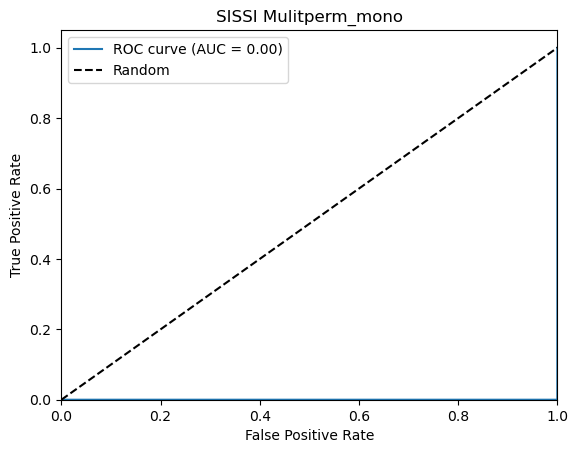

In [ ]:
positive_file = df[["sissi_oversampling"]]
negative_file = df[["multiperm_mono"]]
title = "SISSI Mulitperm_mono"
receiverOperationCharacteristics(positive_file, negative_file, title)

In [ ]:
# threshold = -3
# df["multiperm_mono_binary"] = (df["multiperm_mono"] > threshold).astype(int)

# # Trainings- und Testdatensatz aufteilen
# X_train, X_test, y_train, y_test = train_test_split(df[["sissi"]], df["multiperm_mono_binary"], test_size=0.3, random_state=42)

# # Logistische Regression
# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)

# # Wahrscheinlichkeiten für Klasse 1
# y_scores = model.predict_proba(X_test)[:, 1]


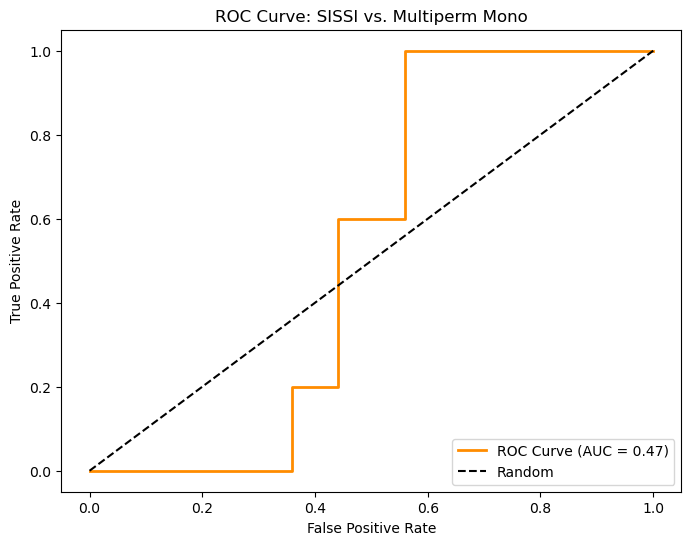

AUC: 0.47


In [ ]:
# # ROC-Kurve berechnen
# fpr, tpr, thresholds = roc_curve(y_test, y_scores)
# auc_score = auc(tpr, fpr)

# # ROC-Kurve plotten
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})', color='darkorange', lw=2)
# plt.plot([0, 1], [0, 1], 'k--', label='Random')  # Diagonale
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('ROC Curve: SISSI vs. Multiperm Mono')
# plt.legend(loc="lower right")
# plt.show()

# print(f"AUC: {auc_score:.2f}")